# Predicted Intensities for Holdout Test Set

In [1]:
# Author information
__author__ = "Kevin McCoy"
__copyright__ = "Copyright 2024, Ahmad"
__credits__ = ["Kevin McCoy", "Christine Peterson", "Moiz Ahmad"]
__license__ = "MIT"
__version__ = "1.0.0"
__maintainer__ = "Kevin McCoy"
__email__ = ["kmccoy1@rice.edu", "cbpeterson@mdanderson.org", "MAhmad@mdanderson.org"]
__status__ = "released"
__date__ = "2024-03-18" # Last modified date

In [2]:
# Import basic libraries
import pandas as pd
import numpy as np
import random
import math
from sklearn import metrics
from sklearn import preprocessing
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

# Import model used
from sklearn.ensemble import RandomForestClassifier

# Graphics libraries
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
import statsmodels.api as sm

## Test Performance

In [3]:
# Function to predict on test set
def predict(pred_method, clf, X_val, val_patient):
    
    # Predict on test set normally
    if pred_method == 'standard':
        y_pred = clf.predict(X_val)

    # Extract at least 3 postive objects per person
    else:
        
        # Get probability of positive class
        y_pred = clf.predict_proba(X_val)

        # Initialize output array
        y_out = np.empty((len(y_pred)))
        
        # Loop through each patient
        for i, proba in enumerate(y_pred):
            
            # Get current patient
            curr_patient = val_patient[i]
            
            # Get all probabilities for current patient
            mask = (val_patient == curr_patient)
            probs = y_pred[mask.flatten(), :]
            
            # Sort probabilities
            sorted_index_array = np.argsort(probs[:,1])
            sorted_probs = probs[sorted_index_array]
            
            # If there are at least 3 positive objects, extract them
            if np.any(proba[1] == sorted_probs[-3:, 1]) or proba[1] > 0.50:
                y_out[i] = 1
            else:
                y_out[i] = 0
        
        # Set output array to be the predicted values
        y_pred = y_out
    
    # Return predicted values
    return y_pred

In [4]:
random.seed(8675309) # Jenny, I got your number

FILENAME = r"./data/og_data.xlsx"

clf = RandomForestClassifier(max_samples=0.66, class_weight={0: 1, 1: 1}, n_estimators=1000, n_jobs=-1, random_state=8675309)

###############################################################################

# Read in data
print("Loading Dataset...")
df_og = pd.read_excel(FILENAME)

# Extract dependent variables of interest
labels_data = df_og[['label0','label1','label2']].to_numpy()
y0 = labels_data[:,0]

# Clean Data
df = df_og.drop(['label0','label1','label2'], axis=1) #Drop label columns from list of X columns
metadata = df[['Unnamed: 0','Study ID','ParticleNumber in Study','Num_slices']]
df = df.drop(['Unnamed: 0','Study ID','ParticleNumber in Study','Num_slices'],axis=1) #Drop study metadata

# Drop features 
df = df.drop(['Slice'],axis=1)
df = df.drop(['Exp_Skew'],axis=1) # Missing data in this feature column
df = df.drop(['Exp_Kurt'],axis=1) # Missing data in this feature column

# Drop features with high correlation
df = df.drop(['XM', 'BX', 'FeretX', 'YM', 'BY', 'FeretY'], axis=1)

# Optionally, drop 'Mean' feature
df = df.drop(['Mean'], axis=1)

# Export to numpy array
X = df.to_numpy()

# Get study ID
patient = metadata['Study ID'].to_numpy() # Patient number

# Get test and train indices
test_percentage = 0.2 # Edit as you like
num_patients = max(patient)
test_idx = random.sample(range(1, num_patients+1), math.floor(test_percentage*num_patients))
test_rows = metadata['Study ID'].isin(test_idx).to_numpy()

###############################################################################

# Split data into test and train
X_train = X[~test_rows, :]
X_test = X[test_rows, :]

# For single class, invert so that 1 is postive reading
y_train = 1-y0[~test_rows]
y_test = 1-y0[test_rows]

# normalize data
scaler = preprocessing.StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

# Fit model
clf.fit(X_train, y_train)

# Get patient numbers
test_patient = patient[test_rows]

# Predict on test set
pred_method = 'full' # Extract at least 3 postive objects per person
# pred_method = 'standard' # Standard prediction method
y_pred = predict(pred_method, clf, X_test, test_patient)

# Calculate performance metrics
prec = metrics.precision_score(y_test, y_pred)
recall = metrics.recall_score(y_test, y_pred)
auc = metrics.roc_auc_score(y_test, y_pred)

# Print performance metrics
print(f"Precision: {prec:.3f}")
print(f"Recall: {recall:.3f}")
print(f"AUC: {auc:.3f}")

Loading Dataset...
Precision: 0.788
Recall: 0.235
AUC: 0.617


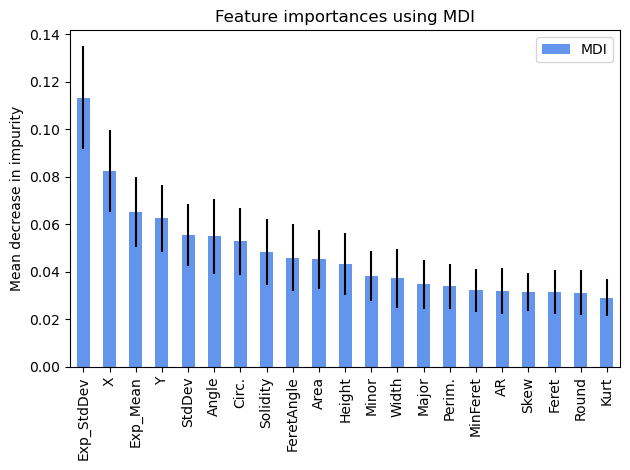

In [5]:
# Print feature importance plot

importances = clf.feature_importances_
feature_names = df.columns

std = np.std([tree.feature_importances_ for tree in clf.estimators_], axis=0)

forest_importances = pd.DataFrame({'MDI': importances, 'std': std}, index=feature_names)
forest_importances = forest_importances.sort_values(by=['MDI'], ascending=False)

std = forest_importances['std']
forest_importances = forest_importances.drop(['std'], axis=1)

fig, ax = plt.subplots()
forest_importances.plot.bar(yerr=std, ax=ax, color="cornflowerblue")
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()

fig.savefig('./figures/feature_importance.pdf', dpi=600)


In [6]:
metrics.confusion_matrix(y_test, y_pred, labels=[1, 0])

array([[   78,   254],
       [   21, 24904]])

## Predicted Intensities

In [7]:
# Extract needed information from test set
test_df = df_og.iloc[test_rows, :]
test_df = test_df.loc[:, ['Study ID', 'Slice',  'Mean']]
test_df['predicted_label'] = y_pred
test_df = test_df[test_df['predicted_label'] == 1]

In [8]:
# Initialize Output Dataframe
out_df = pd.DataFrame(columns=['Study ID', 'Median', 'StDev', 'Num_slices'])

# Loop through each study ID
for idx in test_idx:
    count = Counter(test_df['Study ID'])[idx]
    median = np.median(test_df[test_df['Study ID'] == idx]['Mean']) 
    stDev = np.std(test_df[test_df['Study ID'] == idx]['Mean'])
    
    new_row = pd.DataFrame([[idx, median, stDev, count]], columns=['Study ID', 'Median', 'StDev', 'Num_slices'])
    out_df = pd.concat([out_df, new_row], ignore_index=True)


/var/folders/wm/2drf_bfd1kd_992mj3hlps740000gn/T/ipykernel_74308/2782174069.py:11: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  out_df = pd.concat([out_df, new_row], ignore_index=True)


In [9]:
out_df['Study ID'] = out_df['Study ID'].astype('int')
out_df['Num_slices'] = out_df['Num_slices'].astype('int')
out_df.sort_values(by=['Study ID'], inplace=True)

In [10]:
preds = out_df['Median'].to_numpy()

# Human Labelled Intensities

In [11]:
df = pd.read_excel(r"./data/og_labels.xlsx")
df.head()

,Dataset,Label 1,Label 2,PV HU,Slice,Moiz's comments,Sujay's comments
0,1,"578, 557, 546","1044, 616, 608, 599, 589, 567",172.4,90,NaN,NaN
1,2,"791, 779, 767, 756, 746, 737, 727, 720, 713, 7...","925, 909, 892, 881, 871, 859, 850, 838, 828, 8...",145.3,82,NaN,NaN
2,3,"548, 542","628, 622, 616, 611, 572, 566, 560, 555, 550,",145.7,87,NaN,NaN
3,4,"536, 527, 519, 502, 494, 485, 479, 472,","622, 614, 606, 597, 587, 578, 569, 545, 464, 4...",121.6,91,NaN,NaN
4,5,"1044, 1030, 1016, 1002, 988, 975, 962, 950, 93...",NaN,185.0,103,NaN,A LOT OF INTERFERENCE - (RELATIVELY HIGH INTEN...


In [12]:
# Clean data
df = df[['Dataset', 'PV HU']]
df = df[df['Dataset'].isin(test_idx)]
df.sort_values(by=['Dataset'], inplace=True)

## Figure Generation

In [13]:
true = df['PV HU'].to_numpy()

print(f"MAD: {np.mean(np.abs(true - preds)):.3f}")
print(f"RMSE: {np.sqrt(np.mean((true - preds)**2)):.3f}")

MAD: 13.400
RMSE: 30.085


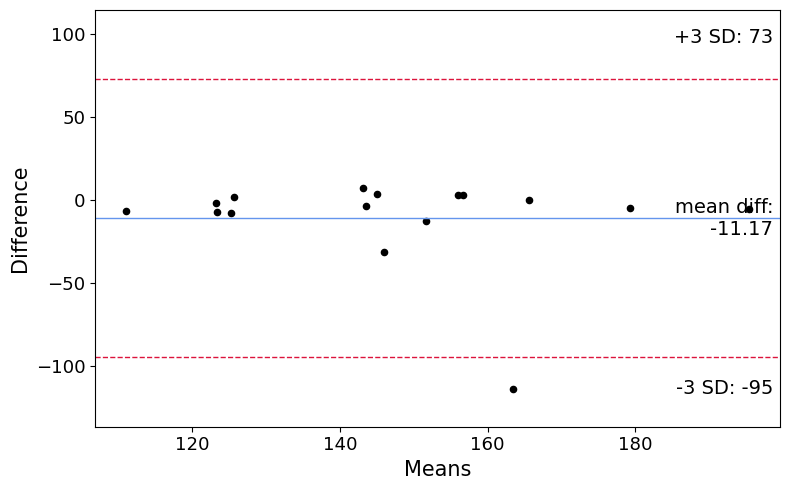

In [14]:
# create Bland-Altman plot                  
f, ax = plt.subplots(1, figsize = (8,5))
sm.graphics.mean_diff_plot(preds, true, ax = ax, scatter_kwds={'c':'black'}, 
                           mean_line_kwds={'c':'cornflowerblue'}, 
                           limit_lines_kwds={'c':'crimson'}, sd_limit=3)

#display Bland-Altman plot
plt.savefig('./figures/ba_int.pdf', dpi=600)